In [9]:
# ============================================================
# Credit Card Fraud Detection
# Step 2: Feature Engineering
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [10]:
df = pd.read_csv(r'C:\Users\harsh\Downloads\fraude detection\creditcard.csv')
df = df.drop_duplicates()
print("Shape:", df.shape)
df.head()

Shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


=== Skewness of Amount and Time ===
Amount Skewness: 16.978803370060476
Time Skewness: -0.03558064623598201


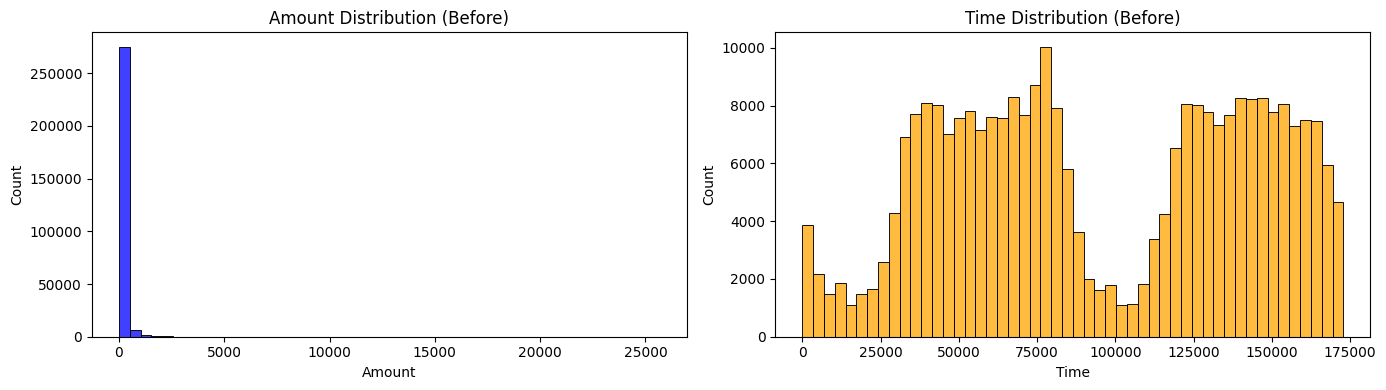

In [11]:
print("=== Skewness of Amount and Time ===")
print("Amount Skewness:", df['Amount'].skew())
print("Time Skewness:", df['Time'].skew())

fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df['Amount'], ax=axes[0], color='blue', bins=50)
axes[0].set_title('Amount Distribution (Before)')

sns.histplot(df['Time'], ax=axes[1], color='orange', bins=50)
axes[1].set_title('Time Distribution (Before)')
plt.tight_layout()
plt.show()

In [12]:
# RobustScaler is better for fraud detection (handles outliers well)
rob_scaler = RobustScaler()

df['NormalizedAmount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['NormalizedTime'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop original columns
df.drop(['Amount', 'Time'], axis=1, inplace=True)

print("Done! New Shape:", df.shape)
df.head()

Done! New Shape: (283726, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,NormalizedAmount,NormalizedTime
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.774718,-0.995290
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.268530,-0.995290
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.959811,-0.995279
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.411487,-0.995279
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.667362,-0.995267


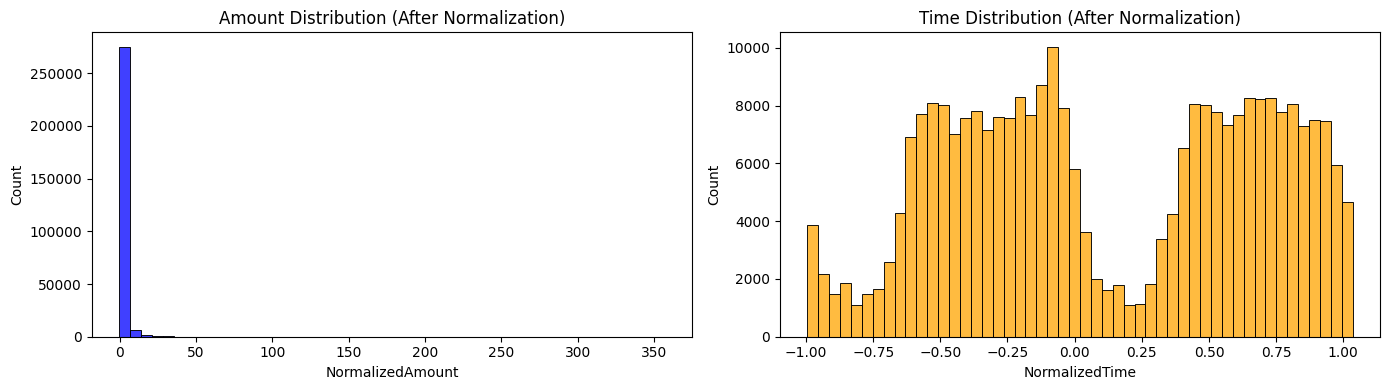

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df['NormalizedAmount'], ax=axes[0], color='blue', bins=50)
axes[0].set_title('Amount Distribution (After Normalization)')

sns.histplot(df['NormalizedTime'], ax=axes[1], color='orange', bins=50)
axes[1].set_title('Time Distribution (After Normalization)')
plt.tight_layout()
plt.show()

In [14]:
# Check class counts
print("Class Distribution:\n", df['Class'].value_counts())

fraud_df = df[df['Class'] == 1]
legit_df = df[df['Class'] == 0]

print("\nFraud samples:", len(fraud_df))
print("Legit samples:", len(legit_df))

# Undersample legitimate transactions
legit_sample = legit_df.sample(n=len(fraud_df), random_state=42)

# Combine
new_df = pd.concat([fraud_df, legit_sample], axis=0).reset_index(drop=True)

print("\nNew Dataset Shape:", new_df.shape)
print("New Class Distribution:\n", new_df['Class'].value_counts())

Class Distribution:
 Class
0    283253
1       473
Name: count, dtype: int64

Fraud samples: 473
Legit samples: 283253

New Dataset Shape: (946, 31)
New Class Distribution:
 Class
1    473
0    473
Name: count, dtype: int64


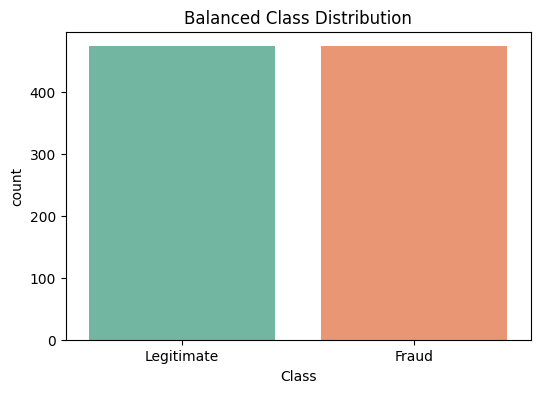

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=new_df, palette='Set2')
plt.title('Balanced Class Distribution')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()

In [16]:
new_df.to_csv(r'C:\Users\harsh\Downloads\fraude detection\engineered_data.csv', index=False)
print("Engineered dataset saved! ✅")

Engineered dataset saved! ✅
